**This classifeir uses TF-IDF**


In [1]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch import nn
import tqdm
from timeit import default_timer as timer
from sklearn.model_selection import train_test_split
from scipy import sparse
# from malware_supcons import MalDectModel
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

**load data**


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'



df = pd.read_csv("F:\\university\\projects\\malware api call\\Malware Analysis Datasets API Call Sequences\\archive\dynamic_api_call_sequence_per_malware_100_0_306.csv")


lables = df['malware']
Y = torch.tensor(lables)

df = df.drop(columns=['hash', 'malware'])

X = df.values.tolist()

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shahin\AppData\Local\Temp\ipykernel_3228\2378507886.py:5: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("F:\\university\\projects\\malware api call\\Malware Analysis Datasets API Call Sequences\\archive\dynamic_api_call_sequence_per_malware_100_0_306.csv")


**Pre Process**

In [3]:



device = 'cuda' if torch.cuda.is_available() else 'cpu'


X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.2
                                                    , random_state=42, shuffle=True)







** Dataset**

In [4]:


class ApiDataSet(Dataset):
    def __init__(self, data, labels):
        super().__init__()
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]  # shape [input_size=278]
        y = self.labels[idx]
        x = torch.tensor(x, dtype= torch.float32)

        # Gaussian noise
        # Add seq_len=1 dimension
                 # [1, 278]
        x = x.unsqueeze(0)
        return x, y



dataset_train = ApiDataSet(X_train, y_train)

data_loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)


dataset_test = ApiDataSet(X_test, y_test)

data_loader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)


device = 'cuda' if torch.cuda.is_available() else 'cpu'

**Model**

In [5]:
class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))



class Classifier():
    def __init__(self):
        self.model = LogisticRegression(penalty='l2', solver='saga', )
         


class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))
    

**Train and Test**

In [6]:
def get_feature(model, data_loader):
    model.eval()

    X_list , Y_list = [], []
    for (x, y ) in data_loader:

        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            output, [hidden, cell]  = model.lstm(x)
            features = hidden[-1]


        if len(y.shape) > 1 and y.shape[1] == 1:
          y = y.squeeze(1)
        elif len(y.shape) > 1:
          y = torch.argmax(y, dim=1)

        x = features.cpu().numpy()
        y = y.cpu().numpy()
        X_list.append(x)
        Y_list.append(y)
    X_list = np.vstack(X_list)
    Y_list = np.concatenate(Y_list)    
        
    
    return X_list, Y_list



    # Metrics
    # test_loss = test_loss / len(test_data_loader)
    # test_acc = accuracy_score(all_labels, all_preds)
    # test_f1 = f1_score(all_labels, all_preds, average='binary')
    # test_auc = roc_auc_score(all_labels, all_probs)

    # return test_loss, test_acc, test_f1, test_auc


def train(model, classifier, train_data_loader, test_data_loader):
    test_loss, test_acc, test_prec, test_rec, test_f1, test_auc = 0, 0 , 0, 0 , 0, 0
    train_loss = 0

    X_train , y_train = get_feature(model, train_data_loader)
    X_test, y_test = get_feature(model, test_data_loader)

    params_grid = {
        'solver' :['saga', 'lbfgs'],
        'penalty' : ['l1', 'l2']
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

    grid = GridSearchCV(
        estimator=classifier,
        param_grid=params_grid,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'f1_macro': 'f1_macro',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'auc_ovr': 'roc_auc_ovr'     # AUC for training folds
        },
        refit='f1_macro'                # model selection based on macro-F1
    )

    grid.fit(X_train, y_train)

    # --------------------------------------
    # TRAIN (CV) METRICS
    # --------------------------------------
    cv_results = grid.cv_results_
    best_idx = grid.best_index_

    train_acc = cv_results['mean_test_accuracy'][best_idx]
    train_f1_macro = cv_results['mean_test_f1_macro'][best_idx]
    train_prec_macro = cv_results['mean_test_precision_macro'][best_idx]
    train_rec_macro = cv_results['mean_test_recall_macro'][best_idx]
    train_auc = cv_results['mean_test_auc_ovr'][best_idx]

    print("======== TRAIN (CV) RESULTS ========")
    print(f"Accuracy (CV):          {train_acc:.4f}")
    print(f"F1-Macro (CV):          {train_f1_macro:.4f}")
    print(f"Precision-Macro (CV):   {train_prec_macro:.4f}")
    print(f"Recall-Macro (CV):      {train_rec_macro:.4f}")
    print(f"AUC (OvR) (CV):         {train_auc:.4f}")
    print("Best Params:", grid.best_params_)
    print("====================================\n")

    # --------------------------------------
    # TEST METRICS
    # --------------------------------------
    y_pred = grid.predict(X_test)
    y_pred_prob = grid.predict_proba(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    test_f1_macro = f1_score(y_test, y_pred, average='macro')
    test_f1_weighted = f1_score(y_test, y_pred, average='weighted')

    test_prec_macro = precision_score(y_test, y_pred, average='macro')
    test_prec_weighted = precision_score(y_test, y_pred, average='weighted')

    test_rec_macro = recall_score(y_test, y_pred, average='macro')
    test_rec_weighted = recall_score(y_test, y_pred, average='weighted')


    if y_pred_prob.shape[1]==2:
        test_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
    else:   
        test_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')

    print("=========== TEST RESULTS ===========")
    print(f"Accuracy:               {test_acc:.4f}")
    print(f"F1-Macro:               {test_f1_macro:.4f}")
    print(f"F1-Weighted:            {test_f1_weighted:.4f}")
    print(f"Precision-Macro:        {test_prec_macro:.4f}")
    print(f"Precision-Weighted:     {test_prec_weighted:.4f}")
    print(f"Recall-Macro:           {test_rec_macro:.4f}")
    print(f"Recall-Weighted:        {test_rec_weighted:.4f}")
    print(f"AUC (OvR):              {test_auc:.4f}")
    print("====================================\n")

    # --------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------
    cm = confusion_matrix(y_test, y_pred)
    classes = ['Benign', 'Malware']
    print(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    #     # log scalars (to see curves)
     
    # writer.add_scalar("Metrics/accuracy", test_acc)
    # writer.add_scalar("Metrics/precision", test_prec)
    # writer.add_scalar("Metrics/recall", test_rec)
    # writer.add_scalar("Metrics/f1", test_f1)
    # writer.add_scalar("Metrics/auc", test_auc)

    # # after training: log hparams + final metrics
    # hparams = {
    #     "ngram_min": 3,
    #     "ngram_max": 4,
    #     "learning_rate": 1e-4,
    # }
        

    # metrics = {
    #     "final_test_acc": test_acc,
    #     "final_test_prec": test_prec,
    #     "final_test_rec": test_rec,
    #     "final_test_f1": test_f1,
    #     "final_test_auc": test_auc,
    # }

    # writer.add_hparams(hparams, metrics)
    # writer.close()

**Main**

c:\Users\shahin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\shahin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\shahin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\shahin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\shahin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means

======== TRAIN (CV) RESULTS ========
Accuracy (CV):          0.9754
F1-Macro (CV):          0.5006
Precision-Macro (CV):   0.6058
Recall-Macro (CV):      0.5033
AUC (OvR) (CV):         0.5023
Best Params: {'penalty': 'l2', 'solver': 'saga'}

=========== TEST RESULTS ===========
Accuracy:               0.9739
F1-Macro:               0.4934
F1-Weighted:            0.9614
Precision-Macro:        0.4871
Precision-Weighted:     0.9492
Recall-Macro:           0.4998
Recall-Weighted:        0.9739
AUC (OvR):              0.5024

[[   0  226]
 [   3 8547]]


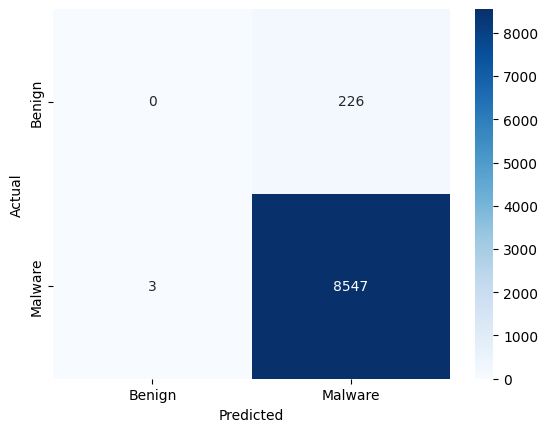

Time taken: 105.39066250000178


In [7]:
from tqdm.auto import tqdm


if __name__ == "__main__":

    torch.manual_seed(42)
    
    model  = MalDectModel(input_size=len(X_train[0]), 
                          hidden_dim=128, projection_dim=128)
    start_time = timer()    
    model_save_path = "F:\\university\\projects\\malware_api_detection_using_supcons\\malware analyse dataset\\supconModel_v2_imbalance"
    model.load_state_dict(torch.load(f=model_save_path))


    epochs = 100
    classifier = Classifier().model


    
    train(model=model, 
          train_data_loader=data_loader_train, classifier=classifier,test_data_loader=data_loader_test)
    end_time  = timer()
    print(f"Time taken: {end_time - start_time}")